**LOADING MOVIES**

In [3]:
import requests
import pandas as pd
import os
from dotenv import load_dotenv
import numpy as np

In [4]:


load_dotenv()

API_KEY = os.getenv("API_KEY")

movies = []

movie_ids=[0, 299534, 19995, 140607, 299536, 597, 135397, 420818, 24428, 168259, 99861, 284054, 12445, 181808, 330457, 351286, 109445, 321612, 260513]

for movie_id in movie_ids:
    
    if movie_id == 0:
        continue
        
    url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key={API_KEY}"
    
    response = requests.get(url)
    
    if response.status_code == 200:
        movies.append(response.json())

df = pd.DataFrame(movies)

print(df.columns)


Index(['adult', 'backdrop_path', 'belongs_to_collection', 'budget', 'genres',
       'homepage', 'id', 'imdb_id', 'origin_country', 'original_language',
       'original_title', 'overview', 'popularity', 'poster_path',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'video', 'vote_average', 'vote_count'],
      dtype='object')


In [5]:
print(df.head(10))

   adult                     backdrop_path  \
0  False  /7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg   
1  False  /vL5LR6WdxWPjLPFRLe133jXWsh5.jpg   
2  False  /8BTsTfln4jlQrLXUBquXJ0ASQy9.jpg   
3  False  /mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg   
4  False  /qBChUbS8ksbJoPTfZpogsnxG5tY.jpg   
5  False  /s5QfDFqRO6sjgPtKkjxD0WqXQef.jpg   
6  False  /1TUg5pO1VZ4B0Q1amk3OlXvlpXV.jpg   
7  False  /9BBTo63ANSmhC4e6r62OJFuK2GL.jpg   
8  False  /ehzI1mVcnHqB58NqPyQwpMqcVoz.jpg   
9  False  /kIBK5SKwgqIIuRKhhWrJn3XkbPq.jpg   

                               belongs_to_collection     budget  \
0  {'id': 86311, 'name': 'The Avengers Collection...  356000000   
1  {'id': 87096, 'name': 'Avatar Collection', 'po...  237000000   
2  {'id': 10, 'name': 'Star Wars Collection', 'po...  245000000   
3  {'id': 86311, 'name': 'The Avengers Collection...  300000000   
4                                               None  200000000   
5  {'id': 328, 'name': 'Jurassic Park Collection'...  150000000   
6  {'id': 762512, 'name'

**DROPPING UNNECESSARY COLUMNS**

In [6]:
columns_to_drop=['adult', 'imdb_id', 'original_title', 'video', 'homepage']
df.drop(columns=columns_to_drop, inplace=True)

**EVALUATING JSON-LIKE COLUMNS**

In [7]:
df['spoken_languages'].head(10)

0    [{'english_name': 'English', 'iso_639_1': 'en'...
1    [{'english_name': 'English', 'iso_639_1': 'en'...
2    [{'english_name': 'English', 'iso_639_1': 'en'...
3    [{'english_name': 'English', 'iso_639_1': 'en'...
4    [{'english_name': 'English', 'iso_639_1': 'en'...
5    [{'english_name': 'English', 'iso_639_1': 'en'...
6    [{'english_name': 'English', 'iso_639_1': 'en'...
7    [{'english_name': 'English', 'iso_639_1': 'en'...
8    [{'english_name': 'Arabic', 'iso_639_1': 'ar',...
9    [{'english_name': 'English', 'iso_639_1': 'en'...
Name: spoken_languages, dtype: object

In [8]:
def extract_names(x):
    
    if isinstance(x, list):
        # return "|".join([item["name"] for item in x if "name" in item])
        return "| ".join([d["name"] for d in x])
    return None

cols = ['genres', 'production_countries', 'production_companies', 'spoken_languages']

for col in cols:
    df[col] = df[col].apply(extract_names)

df['belongs_to_collection'] = df['belongs_to_collection'].apply(
    lambda x: x['name'] if isinstance(x, dict) else None
)


In [9]:
df.head(10)

,backdrop_path,belongs_to_collection,budget,genres,id,origin_country,original_language,overview,popularity,poster_path,...,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,The Avengers Collection,356000000,Adventure| Science Fiction| Action,299534,[US],en,After the devastating events of Avengers: Infi...,19.4282,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,...,United States of America,2019-04-24,2799439100,181,English| 日本語|,Released,Avenge the fallen.,Avengers: Endgame,8.235,27378
1,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,Avatar Collection,237000000,Action| Adventure| Science Fiction,19995,[US],en,"In the 22nd century, a paraplegic Marine is di...",28.1058,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,...,United States of America| United Kingdom,2009-12-16,2923706026,162,English| Español,Released,Enter the world of Pandora.,Avatar,7.600,33624
2,/8BTsTfln4jlQrLXUBquXJ0ASQy9.jpg,Star Wars Collection,245000000,Adventure| Action| Science Fiction,140607,[US],en,Thirty years after defeating the Galactic Empi...,10.6791,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,...,United States of America,2015-12-15,2068223624,136,English,Released,Every generation has a story.,Star Wars: The Force Awakens,7.250,20354
3,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,The Avengers Collection,300000000,Adventure| Action| Science Fiction,299536,[US],en,As the Avengers and their allies have continue...,34.2807,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,...,United States of America,2018-04-25,2052415039,149,English|,Released,Destiny arrives all the same.,Avengers: Infinity War,8.234,31616
4,/qBChUbS8ksbJoPTfZpogsnxG5tY.jpg,None,200000000,Drama| Romance,597,[US],en,101-year-old Rose DeWitt Bukater tells the sto...,28.7289,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,...,United States of America,1997-12-18,2264162353,194,English| Français| Deutsch| svenska| Italiano|...,Released,Nothing on earth could come between them.,Titanic,7.903,26896
5,/s5QfDFqRO6sjgPtKkjxD0WqXQef.jpg,Jurassic Park Collection,150000000,Action| Adventure| Science Fiction| Thriller,135397,[US],en,Twenty-two years after the events of Jurassic ...,10.6075,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,...,United States of America,2015-06-06,1671537444,124,English,Released,The park is open.,Jurassic World,6.699,21397
6,/1TUg5pO1VZ4B0Q1amk3OlXvlpXV.jpg,The Lion King (Reboot) Collection,260000000,Adventure| Drama| Family| Animation,420818,[US],en,"Simba idolizes his father, King Mufasa, and ta...",9.6413,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,...,United States of America,2019-07-12,1662020819,118,English,Released,The king has returned.,The Lion King,7.098,10671
7,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,The Avengers Collection,220000000,Science Fiction| Action| Adventure,24428,[US],en,When an unexpected enemy emerges and threatens...,49.1925,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,...,United States of America,2012-04-25,1518815515,143,English| हिन्दी| Pусский,Released,Some assembly required.,The Avengers,7.969,36541
8,/ehzI1mVcnHqB58NqPyQwpMqcVoz.jpg,The Fast and the Furious Collection,190000000,Action| Crime| Thriller,168259,[US],en,Deckard Shaw seeks revenge against Dominic Tor...,9.9484,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,...,United States of America,2015-04-01,1515400000,139,العربية| English| Español| ภาษาไทย,Released,Vengeance hits home.,Furious 7,7.219,11183
9,/kIBK5SKwgqIIuRKhhWrJn3XkbPq.jpg,The Avengers Collection,235000000,Action| Adventure| Science Fiction,99861,[US],en,When Tony Stark tries to jumpstart a dormant p...,15.4938,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,...,United States of America,2015-04-22,1405403694,141,English,Released,A new age has come.,Avengers: Age of Ultron,7.270,24199


**INSPECTING EXTRACTED COLUMNS**

In [10]:
columns = [
    "belongs_to_collection",
    "genres",
    "spoken_languages",
    "production_countries",
    "production_companies"
]

for col in columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(20))


--- belongs_to_collection ---
belongs_to_collection
The Avengers Collection                4
Star Wars Collection                   2
None                                   2
Jurassic Park Collection               2
Frozen Collection                      2
Avatar Collection                      1
The Lion King (Reboot) Collection      1
The Fast and the Furious Collection    1
Black Panther Collection               1
Harry Potter Collection                1
The Incredibles Collection             1
Name: count, dtype: int64

--- genres ---
genres
Action| Adventure| Science Fiction               3
Adventure| Action| Science Fiction               3
Action| Adventure| Science Fiction| Thriller     2
Adventure| Science Fiction| Action               1
Drama| Romance                                   1
Adventure| Drama| Family| Animation              1
Science Fiction| Action| Adventure               1
Action| Crime| Thriller                          1
Adventure| Fantasy                     

In [11]:
#Detect Missing Data
df[columns].isna().sum()

belongs_to_collection    2
genres                   0
spoken_languages         0
production_countries     0
production_companies     0
dtype: int64

In [12]:
df[columns] = df[columns].fillna("Unknown")

In [13]:
df[columns].isna().sum()

belongs_to_collection    0
genres                   0
spoken_languages         0
production_countries     0
production_companies     0
dtype: int64

**CONVERTING COLUMNS DATATYPES**

In [14]:
numeric_cols = ["budget", "id", "popularity", "revenue", "runtime", "vote_average", "vote_count"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

#Convert release_date to datetime
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

**REPLACE UNREALISTIC VALUES**

In [15]:
#Replace 0 in budget / revenue / runtime with NaN

cols_zero_nan = ["budget", "revenue", "runtime"]

for col in cols_zero_nan:
    df[col] = df[col].replace(0, np.nan)

#Convert budget and revenue to million USD
df["budget_million"] = df["budget"] / 1_000_000
df["revenue_million"] = df["revenue"] / 1_000_000

#Handle movies with vote_count = 0
df.loc[df["vote_count"] == 0, "vote_average"] = np.nan

#Clean overview and tagline

placeholders = ["No Data", "N/A", "None", ""]

df["overview"] = df["overview"].replace(placeholders, np.nan)
df["tagline"] = df["tagline"].replace(placeholders, np.nan)

In [16]:
#Remove Duplicates and Invalid Rows
#Remove duplicate movies
df = df.drop_duplicates(subset="id")
#Remove rows with missing id or title
df = df.dropna(subset=["id", "title"])
#Keep Rows With At Least 10 Non-NaN Values
df = df.dropna(thresh=10)

#Keep Only Released Movies
df = df[df["status"] == "Released"]

#Drop the status column afterwards:
df = df.drop(columns=["status"])

In [17]:
# Columns you want to ensure exist
optional_cols = ['cast', 'cast_size', 'director', 'crew_size']

for col in optional_cols:
    if col not in df.columns:
        df[col] = None  # or np.nan


final_columns = [
    'id', 'title', 'tagline', 'release_date', 'genres', 'belongs_to_collection',
    'original_language', 'budget_million', 'revenue_million',
    'production_companies', 'production_countries',
    'vote_count', 'vote_average', 'popularity', 'runtime',
    'overview', 'spoken_languages', 'poster_path', 
    'cast', 'cast_size', 'director', 'crew_size'
]

In [18]:
df = df[final_columns]
df = df.reset_index(drop=True)

In [19]:
df.head(10)

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_million,revenue_million,production_companies,...,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure| Science Fiction| Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,8.235,19.4282,181,After the devastating events of Avengers: Infi...,English| 日本語|,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,None,None,None,None
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action| Adventure| Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment| Lightstorm Entertainment| ...,...,7.600,28.1058,162,"In the 22nd century, a paraplegic Marine is di...",English| Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,None,None,None,None
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure| Action| Science Fiction,Star Wars Collection,en,245.0,2068.223624,Lucasfilm Ltd.| Bad Robot,...,7.250,10.6791,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,None,None,None,None
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Adventure| Action| Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,8.234,34.2807,149,As the Avengers and their allies have continue...,English|,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,None,None,None,None
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama| Romance,Unknown,en,200.0,2264.162353,Paramount Pictures| 20th Century Fox| Lightsto...,...,7.903,28.7289,194,101-year-old Rose DeWitt Bukater tells the sto...,English| Français| Deutsch| svenska| Italiano|...,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,None,None,None,None
5,135397,Jurassic World,The park is open.,2015-06-06,Action| Adventure| Science Fiction| Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment| Universal Pictures| Lege...,...,6.699,10.6075,124,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,None,None,None,None
6,420818,The Lion King,The king has returned.,2019-07-12,Adventure| Drama| Family| Animation,The Lion King (Reboot) Collection,en,260.0,1662.020819,Walt Disney Pictures| Fairview Entertainment,...,7.098,9.6413,118,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,None,None,None,None
7,24428,The Avengers,Some assembly required.,2012-04-25,Science Fiction| Action| Adventure,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,7.969,49.1925,143,When an unexpected enemy emerges and threatens...,English| हिन्दी| Pусский,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,None,None,None,None
8,168259,Furious 7,Vengeance hits home.,2015-04-01,Action| Crime| Thriller,The Fast and the Furious Collection,en,190.0,1515.400000,Original Film| One Race| Universal Pictures,...,7.219,9.9484,139,Deckard Shaw seeks revenge against Dominic Tor...,العربية| English| Español| ภาษาไทย,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,None,None,None,None
9,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action| Adventure| Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,7.270,15.4938,141,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,None,None,None,None


**KPI Implementation & Analysis**

In [20]:
#####Compute Profit and ROI

# Compute profit (in million USD)
df["profit_million"] = df["revenue_million"] - df["budget_million"]

# Compute ROI (Revenue / Budget)
df["roi"] = df["revenue_million"] / df["budget_million"]

# Optional: set ROI to NaN if budget is less than 10 million
df.loc[df["budget_million"] < 10, "roi"] = np.nan


#####Highest Revenue
highest_revenue = df.sort_values(by="revenue_million", ascending=False).head(10)

#####Highest Budget
highest_budget = df.sort_values(by="budget_million", ascending=False).head(10)


####Highest Profit
highest_profit = df.sort_values(by="profit_million", ascending=False).head(10)

#####Lowest Profit
lowest_profit = df.sort_values(by="profit_million", ascending=True).head(10)

#####Highest ROI (Budget ≥ $10M)
highest_roi = df.sort_values(by="roi", ascending=False).head(10)


#####Lowest ROI (Budget ≥ $10M)
lowest_roi = df.sort_values(by="roi", ascending=True).head(10)


####Most Voted Movies
most_voted = df.sort_values(by="vote_count", ascending=False).head(10)


#####Highest Rated Movies (vote_count ≥ 10)
highest_rated = df[df["vote_count"] >= 10].sort_values(by="vote_average", ascending=False).head(10)


####Lowest Rated Movies (vote_count ≥ 10)
lowest_rated = df[df["vote_count"] >= 10].sort_values(by="vote_average", ascending=True).head(10)


#####Most Popular Movies
most_popular = df.sort_values(by="popularity", ascending=False).head(10)

In [21]:
print("Highest revenue:", highest_revenue.head(1))



Highest revenue:       id   title                      tagline release_date  \
1  19995  Avatar  Enter the world of Pandora.   2009-12-16   

                               genres belongs_to_collection original_language  \
1  Action| Adventure| Science Fiction     Avatar Collection                en   

   budget_million  revenue_million  \
1           237.0      2923.706026   

                                production_companies  ... runtime  \
1  Dune Entertainment| Lightstorm Entertainment| ...  ...     162   

                                            overview  spoken_languages  \
1  In the 22nd century, a paraplegic Marine is di...  English| Español   

                        poster_path  cast cast_size director crew_size  \
1  /gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg  None      None     None      None   

  profit_million        roi  
1    2686.706026  12.336312  

[1 rows x 24 columns]


In [22]:
print("Highest bugdet:", highest_budget.head(1))


Highest bugdet:        id              title             tagline release_date  \
0  299534  Avengers: Endgame  Avenge the fallen.   2019-04-24   

                               genres    belongs_to_collection  \
0  Adventure| Science Fiction| Action  The Avengers Collection   

  original_language  budget_million  revenue_million production_companies  \
0                en           356.0        2799.4391       Marvel Studios   

   ... runtime                                           overview  \
0  ...     181  After the devastating events of Avengers: Infi...   

   spoken_languages                       poster_path  cast cast_size  \
0    English| 日本語|   /ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg  None      None   

  director crew_size profit_million       roi  
0     None      None      2443.4391  7.863593  

[1 rows x 24 columns]


In [23]:
print("Highest profit:",highest_profit.head(1))


Highest profit:       id   title                      tagline release_date  \
1  19995  Avatar  Enter the world of Pandora.   2009-12-16   

                               genres belongs_to_collection original_language  \
1  Action| Adventure| Science Fiction     Avatar Collection                en   

   budget_million  revenue_million  \
1           237.0      2923.706026   

                                production_companies  ... runtime  \
1  Dune Entertainment| Lightstorm Entertainment| ...  ...     162   

                                            overview  spoken_languages  \
1  In the 22nd century, a paraplegic Marine is di...  English| Español   

                        poster_path  cast cast_size director crew_size  \
1  /gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg  None      None     None      None   

  profit_million        roi  
1    2686.706026  12.336312  

[1 rows x 24 columns]


In [24]:
print("Lowest profit:",lowest_profit.head(1))


Lowest profit:         id                     title            tagline release_date  \
12  181808  Star Wars: The Last Jedi  Let the past die.   2017-12-13   

                                genres belongs_to_collection  \
12  Adventure| Action| Science Fiction  Star Wars Collection   

   original_language  budget_million  revenue_million production_companies  \
12                en           300.0       1332.69883       Lucasfilm Ltd.   

    ... runtime                                           overview  \
12  ...     152  Rey develops her newly discovered abilities wi...   

    spoken_languages                       poster_path  cast cast_size  \
12           English  /kOVEVeg59E0wsnXmF9nrh6OmWII.jpg  None      None   

   director crew_size profit_million       roi  
12     None      None     1032.69883  4.442329  

[1 rows x 24 columns]


In [25]:
print("Highest roi:",highest_roi.head())


Highest roi:         id                                         title  \
1    19995                                        Avatar   
4      597                                       Titanic   
5   135397                                Jurassic World   
11   12445  Harry Potter and the Deathly Hallows: Part 2   
13  330457                                     Frozen II   

                                      tagline release_date  \
1                 Enter the world of Pandora.   2009-12-16   
4   Nothing on earth could come between them.   1997-12-18   
5                           The park is open.   2015-06-06   
11                               It all ends.   2011-07-12   
13             The past is not what it seems.   2019-11-20   

                                           genres     belongs_to_collection  \
1              Action| Adventure| Science Fiction         Avatar Collection   
4                                  Drama| Romance                   Unknown   
5    Action| Adv

In [26]:
print("Lowest roi:",lowest_roi.head())


Lowest roi:         id                     title                        tagline  \
12  181808  Star Wars: The Last Jedi              Let the past die.   
9    99861   Avengers: Age of Ultron            A new age has come.   
17  260513             Incredibles 2  It's been too long, dahlings.   
6   420818             The Lion King         The king has returned.   
10  284054             Black Panther            Long live the king.   

   release_date                                genres  \
12   2017-12-13    Adventure| Action| Science Fiction   
9    2015-04-22    Action| Adventure| Science Fiction   
17   2018-06-14  Action| Adventure| Animation| Family   
6    2019-07-12   Adventure| Drama| Family| Animation   
10   2018-02-13    Action| Adventure| Science Fiction   

                belongs_to_collection original_language  budget_million  \
12               Star Wars Collection                en           300.0   
9             The Avengers Collection                en           23

In [27]:
print("Most voted:",most_voted.head(1))


Most voted:       id         title                  tagline release_date  \
7  24428  The Avengers  Some assembly required.   2012-04-25   

                               genres    belongs_to_collection  \
7  Science Fiction| Action| Adventure  The Avengers Collection   

  original_language  budget_million  revenue_million production_companies  \
7                en           220.0      1518.815515       Marvel Studios   

   ... runtime                                           overview  \
7  ...     143  When an unexpected enemy emerges and threatens...   

           spoken_languages                      poster_path  cast cast_size  \
7  English| हिन्दी| Pусский  /RYMX2wcKCBAr24UyPD7xwmjaTn.jpg  None      None   

  director crew_size profit_million       roi  
7     None      None    1298.815515  6.903707  

[1 rows x 24 columns]


In [28]:
print("Highest rated:",highest_rated.head(1))


Highest rated:        id              title             tagline release_date  \
0  299534  Avengers: Endgame  Avenge the fallen.   2019-04-24   

                               genres    belongs_to_collection  \
0  Adventure| Science Fiction| Action  The Avengers Collection   

  original_language  budget_million  revenue_million production_companies  \
0                en           356.0        2799.4391       Marvel Studios   

   ... runtime                                           overview  \
0  ...     181  After the devastating events of Avengers: Infi...   

   spoken_languages                       poster_path  cast cast_size  \
0    English| 日本語|   /ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg  None      None   

  director crew_size profit_million       roi  
0     None      None      2443.4391  7.863593  

[1 rows x 24 columns]


In [29]:
print("Lowest rated:",lowest_rated.head(1))


Lowest rated:         id                           title            tagline release_date  \
14  351286  Jurassic World: Fallen Kingdom  The park is gone.   2018-06-06   

                                          genres     belongs_to_collection  \
14  Action| Adventure| Science Fiction| Thriller  Jurassic Park Collection   

   original_language  budget_million  revenue_million  \
14                en           170.0      1310.469037   

                        production_companies  ... runtime  \
14  Amblin Entertainment| Universal Pictures  ...     129   

                                             overview  spoken_languages  \
14  Three years after Jurassic World was destroyed...  English| Pусский   

                         poster_path  cast cast_size director crew_size  \
14  /x2Us3jR6ToMJjbcPbLimYoxf6xr.jpg  None      None     None      None   

   profit_million       roi  
14    1140.469037  7.708641  

[1 rows x 24 columns]


In [30]:
print("Most popular:",most_popular.head(1))

Most popular:       id         title                  tagline release_date  \
7  24428  The Avengers  Some assembly required.   2012-04-25   

                               genres    belongs_to_collection  \
7  Science Fiction| Action| Adventure  The Avengers Collection   

  original_language  budget_million  revenue_million production_companies  \
7                en           220.0      1518.815515       Marvel Studios   

   ... runtime                                           overview  \
7  ...     143  When an unexpected enemy emerges and threatens...   

           spoken_languages                      poster_path  cast cast_size  \
7  English| हिन्दी| Pусский  /RYMX2wcKCBAr24UyPD7xwmjaTn.jpg  None      None   

  director crew_size profit_million       roi  
7     None      None    1298.815515  6.903707  

[1 rows x 24 columns]


**PULLING CREDITS INFO**

In [40]:
import requests
import os
import time
import pandas as pd
from dotenv import load_dotenv

# Load API key
load_dotenv()
API_KEY = os.getenv("API_KEY")

# Function to fetch credits
def get_credits(movie_id):
    url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key={API_KEY}&append_to_response=credits"
    
    response = requests.get(url)
    
    if response.status_code != 200:
        return None, None, None, None
    
    data = response.json()
    
    credits = data.get("credits", {})
    
    # Extract top 5 cast members
    cast_list = credits.get("cast", [])
    cast = [actor["name"] for actor in cast_list[:5]]
    
    # Extract director
    director = None
    for crew_member in credits.get("crew", []):
        if crew_member.get("job") == "Director":
            director = crew_member.get("name")
            break
    
    # Sizes
    cast_size = len(cast_list)
    crew_size = len(credits.get("crew", []))
    
    return "|".join(cast), cast_size, director, crew_size


# -------------------------------
# Apply to DataFrame
# -------------------------------

# Initialize columns (important!)
df["cast"] = None
df["cast_size"] = None
df["director"] = None
df["crew_size"] = None

for i, row in df.iterrows():
    movie_id = int(row["id"])
    
    cast, cast_size, director, crew_size = get_credits(movie_id)
    
    df.at[i, "cast"] = cast
    df.at[i, "cast_size"] = cast_size
    df.at[i, "director"] = director
    df.at[i, "crew_size"] = crew_size
    
    # Avoid hitting API rate limits
    time.sleep(0.25)


# -------------------------------
# Check results
# -------------------------------
print(df[["title", "cast", "director"]].head())

                          title  \
0             Avengers: Endgame   
1                        Avatar   
2  Star Wars: The Force Awakens   
3        Avengers: Infinity War   
4                       Titanic   

                                                cast       director  
0  Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...      Joe Russo  
1  Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...  James Cameron  
2  Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...    J.J. Abrams  
3  Robert Downey Jr.|Chris Evans|Chris Hemsworth|...      Joe Russo  
4  Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...  James Cameron  


**Define the UDF**

In [41]:
import pandas as pd
import numpy as np

def rank_movies(
    df,
    metric,             # Column to rank by, e.g., 'profit_million'
    top=True,           # True = highest first, False = lowest first
    n=10,               # Number of movies to return
    filter_dict=None    # Optional filters, e.g., {'budget_million': '>=10', 'vote_count': '>=50'}
):
    """
    Rank movies based on a specified metric and optional filters.
    
    Parameters:
    - df: pandas DataFrame
    - metric: str, column to rank
    - top: bool, True for highest first, False for lowest first
    - n: int, number of rows to return
    - filter_dict: dict, optional filters in format {'column': 'condition_value'}
    
    Returns:
    - pandas DataFrame of top n ranked movies
    """
    
    filtered_df = df.copy()
    
    # Apply filters
    if filter_dict:
        for col, cond_val in filter_dict.items():
            if isinstance(cond_val, str):
                # Parse condition strings like '>=10', '<50', '==100'
                operator = cond_val[:2] if cond_val[:2] in ['>=', '<=', '=='] else cond_val[0]
                value = float(cond_val[2:] if operator in ['>=', '<=', '=='] else cond_val[1:])
                
                if operator == '>=':
                    filtered_df = filtered_df[filtered_df[col] >= value]
                elif operator == '<=':
                    filtered_df = filtered_df[filtered_df[col] <= value]
                elif operator == '>':
                    filtered_df = filtered_df[filtered_df[col] > value]
                elif operator == '<':
                    filtered_df = filtered_df[filtered_df[col] < value]
                elif operator == '=' or operator == '==':
                    filtered_df = filtered_df[filtered_df[col] == value]
            else:
                # Assume direct equality if not a string
                filtered_df = filtered_df[filtered_df[col] == cond_val]
    
    # Drop rows where metric is NaN
    filtered_df = filtered_df.dropna(subset=[metric])
    
    # Rank
    filtered_df = filtered_df.sort_values(by=metric, ascending=not top)
    
    return filtered_df.head(n)

In [42]:
def movie_search(df, genres=None, actor=None, director=None):
    """
    Filter movies based on genres, actor, and director.
    
    Parameters:
    - df: pandas DataFrame
    - genres: list of genres (e.g., ['Action', 'Science Fiction'])
    - actor: actor name (string)
    - director: director name (string)
    
    Returns:
    - filtered DataFrame
    """
    
    result = df.copy()
    
    # Filter by genres (must contain ALL specified genres)
    if genres:
        for g in genres:
            result = result[result["genres"].str.contains(g, case=False, na=False)]
    
    # Filter by actor
    if actor:
        result = result[result["cast"].str.contains(actor, case=False, na=False)]
    
    # Filter by director
    if director:
        result = result[result["director"].str.contains(director, case=False, na=False)]
    
    return result

In [43]:
search1 = movie_search(
    df,
    genres=["Science Fiction", "Action"],
    actor="Bruce Willis"
)

search1 = search1.sort_values(by="vote_average", ascending=False)

search1[["title", "genres", "cast", "vote_average", "vote_count"]].head(10)

,title,genres,cast,vote_average,vote_count


In [44]:
search2 = movie_search(
    df,
    actor="Uma Thurman",
    director="Quentin Tarantino"
)

search2 = search2.sort_values(by="runtime", ascending=True)

search2[["title", "director", "cast", "runtime", "release_date"]].head(10)

,title,director,cast,runtime,release_date


In [45]:
filtered = movie_search(
    df,
    genres=["Science Fiction", "Action"],
    actor="Bruce Willis"
)

result = rank_movies(
    filtered,
    metric="vote_average",
    top=True,
    n=10,
    filter_dict={"vote_count": ">=50"}
)

result[["title", "vote_average", "vote_count", "genres"]]

,title,vote_average,vote_count,genres


In [46]:
df[["cast", "director"]].head()

,cast,director
0,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,Joe Russo
1,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,James Cameron
2,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,J.J. Abrams
3,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,Joe Russo
4,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,James Cameron


In [47]:
df["genres"].unique()[:10]

array(['Adventure| Science Fiction| Action',
       'Action| Adventure| Science Fiction',
       'Adventure| Action| Science Fiction', 'Drama| Romance',
       'Action| Adventure| Science Fiction| Thriller',
       'Adventure| Drama| Family| Animation',
       'Science Fiction| Action| Adventure', 'Action| Crime| Thriller',
       'Adventure| Fantasy',
       'Family| Animation| Adventure| Comedy| Fantasy'], dtype=object)

**Comparing movie franchises (belongs_to_collection) vs. standalone movies**

In [49]:
# Create a flag: Franchise vs Standalone
df["is_franchise"] = df["belongs_to_collection"].notna() & (df["belongs_to_collection"] != "None")

# Label for readability
df["movie_type"] = df["is_franchise"].map({True: "Franchise", False: "Standalone"})

In [50]:
comparison = df.groupby("movie_type").agg({
    "revenue_million": "mean",
    "roi": "median",
    "budget_million": "mean",
    "popularity": "mean",
    "vote_average": "mean"
}).rename(columns={
    "revenue_million": "Mean Revenue",
    "roi": "Median ROI",
    "budget_million": "Mean Budget",
    "popularity": "Mean Popularity",
    "vote_average": "Mean Rating"
})

print(comparison)

            Mean Revenue  Median ROI  Mean Budget  Mean Popularity  \
movie_type                                                           
Franchise    1691.831828    7.888409   213.777778        17.895872   

            Mean Rating  
movie_type               
Franchise      7.400167  


In [52]:
franchises = df[df["is_franchise"]]

top_franchises = franchises.groupby("belongs_to_collection").agg({
    "revenue_million": "sum",
    "vote_average": "mean",
    "popularity": "mean",
    "id": "count"
}).rename(columns={"id": "num_movies"})

top_franchises = top_franchises.sort_values(by="revenue_million", ascending=False)

top_franchises.head(10)

,revenue_million,vote_average,popularity,num_movies
belongs_to_collection,,,,
The Avengers Collection,7776.073348,7.9270,29.5988,4
Unknown,3530.278317,7.4355,19.7768,2
Star Wars Collection,3400.922454,7.0250,15.8666,2
Jurassic Park Collection,2982.006481,6.6155,10.0939,2
Avatar Collection,2923.706026,7.6000,28.1058,1
Frozen Collection,2727.902485,7.2415,12.8657,2
The Lion King (Reboot) Collection,1662.020819,7.0980,9.6413,1
The Fast and the Furious Collection,1515.400000,7.2190,9.9484,1
Black Panther Collection,1349.926083,7.3620,14.7462,1


In [53]:
top_directors = df.groupby("director").agg({
    "revenue_million": "sum",
    "vote_average": "mean",
    "popularity": "mean",
    "id": "count"
}).rename(columns={"id": "num_movies"})

# Filter directors with at least 2 movies (optional but recommended)
top_directors = top_directors[top_directors["num_movies"] >= 2]

top_directors = top_directors.sort_values(by="revenue_million", ascending=False)

top_directors.head(10)

,revenue_million,vote_average,popularity,num_movies
director,,,,
James Cameron,5187.868379,7.7515,28.41735,2
Joe Russo,4851.854139,8.2345,26.85445,2
Joss Whedon,2924.219209,7.6195,32.34315,2


In [54]:
df_roi = df[df["budget_million"] >= 10]

roi_comparison = df_roi.groupby("movie_type")["roi"].median()

print(roi_comparison)

movie_type
Franchise    7.888409
Name: roi, dtype: float64


In [55]:
comparison.reset_index()

,movie_type,Mean Revenue,Median ROI,Mean Budget,Mean Popularity,Mean Rating
0,Franchise,1691.831828,7.888409,213.777778,17.895872,7.400167


**Find the Most Successful Movie Franchises** 

In [57]:
franchise_df = df[df["belongs_to_collection"].notna() & (df["belongs_to_collection"] != "None")]
franchise_summary = franchise_df.groupby("belongs_to_collection").agg({
    "id": "count",                      # number of movies
    "budget_million": ["sum", "mean"],
    "revenue_million": ["sum", "mean"],
    "vote_average": "mean"
})


In [58]:
franchise_summary.columns = [
    "num_movies",
    "total_budget",
    "mean_budget",
    "total_revenue",
    "mean_revenue",
    "mean_rating"
]
franchise_summary = franchise_summary.sort_values(by="total_revenue", ascending=False)
franchise_summary.head(10)

,num_movies,total_budget,mean_budget,total_revenue,mean_revenue,mean_rating
belongs_to_collection,,,,,,
The Avengers Collection,4,1111.0,277.75,7776.073348,1944.018337,7.9270
Unknown,2,360.0,180.00,3530.278317,1765.139159,7.4355
Star Wars Collection,2,545.0,272.50,3400.922454,1700.461227,7.0250
Jurassic Park Collection,2,320.0,160.00,2982.006481,1491.003241,6.6155
Avatar Collection,1,237.0,237.00,2923.706026,2923.706026,7.6000
Frozen Collection,2,300.0,150.00,2727.902485,1363.951242,7.2415
The Lion King (Reboot) Collection,1,260.0,260.00,1662.020819,1662.020819,7.0980
The Fast and the Furious Collection,1,190.0,190.00,1515.400000,1515.400000,7.2190
Black Panther Collection,1,200.0,200.00,1349.926083,1349.926083,7.3620


In [59]:
franchise_summary = franchise_summary.reset_index()
franchise_summary = franchise_summary[franchise_summary["num_movies"] >= 2]

In [60]:
franchise_summary

,belongs_to_collection,num_movies,total_budget,mean_budget,total_revenue,mean_revenue,mean_rating
0,The Avengers Collection,4,1111.0,277.75,7776.073348,1944.018337,7.9270
1,Unknown,2,360.0,180.00,3530.278317,1765.139159,7.4355
2,Star Wars Collection,2,545.0,272.50,3400.922454,1700.461227,7.0250
3,Jurassic Park Collection,2,320.0,160.00,2982.006481,1491.003241,6.6155
5,Frozen Collection,2,300.0,150.00,2727.902485,1363.951242,7.2415


In [61]:
franchise_summary["roi"] = franchise_summary["total_revenue"] / franchise_summary["total_budget"]

In [62]:
franchise_summary

,belongs_to_collection,num_movies,total_budget,mean_budget,total_revenue,mean_revenue,mean_rating,roi
0,The Avengers Collection,4,1111.0,277.75,7776.073348,1944.018337,7.9270,6.999166
1,Unknown,2,360.0,180.00,3530.278317,1765.139159,7.4355,9.806329
2,Star Wars Collection,2,545.0,272.50,3400.922454,1700.461227,7.0250,6.240225
3,Jurassic Park Collection,2,320.0,160.00,2982.006481,1491.003241,6.6155,9.318770
5,Frozen Collection,2,300.0,150.00,2727.902485,1363.951242,7.2415,9.093008


**Most Successful Directors**

In [ ]:
#Removing missing values for director analysis
director_df = df[df["director"].notna()]

In [64]:
#Aggregate Director Metrics
director_summary = director_df.groupby("director").agg({
    "id": "count",                # number of movies
    "revenue_million": "sum",    # total revenue
    "vote_average": "mean"       # average rating
})

In [68]:
#Rename Columns
director_summary = director_summary.rename(columns={
    "id": "num_movies",
    "revenue_million": "total_revenue",
    "vote_average": "mean_rating"
})

#Filter Meaningful Directors
director_summary = director_summary[director_summary["num_movies"] >= 2]
#sorting by total revenue
director_summary = director_summary.sort_values(by="total_revenue", ascending=False)
director_summary.head(10)

,num_movies,total_revenue,mean_rating
director,,,
James Cameron,2,5187.868379,7.7515
Joe Russo,2,4851.854139,8.2345
Joss Whedon,2,2924.219209,7.6195


In [69]:
director_summary = director_summary.reset_index()

In [70]:
director_summary.sort_values(by="mean_rating", ascending=False)
director_summary["score"] = (
    director_summary["total_revenue"] * 0.5 +
    director_summary["mean_rating"] * 10 * 0.5
)

director_summary.sort_values(by="score", ascending=False)

,director,num_movies,total_revenue,mean_rating,score
0,James Cameron,2,5187.868379,7.7515,2632.691689
1,Joe Russo,2,4851.854139,8.2345,2467.099570
2,Joss Whedon,2,2924.219209,7.6195,1500.207105


In [71]:
director_summary.sort_values(by="num_movies", ascending=False)

,director,num_movies,total_revenue,mean_rating,score
0,James Cameron,2,5187.868379,7.7515,2632.691689
1,Joe Russo,2,4851.854139,8.2345,2467.099570
2,Joss Whedon,2,2924.219209,7.6195,1500.207105


**Plotting**

In [79]:
df_plot = df.dropna(subset=[
    "budget_million", "revenue_million",
    "roi", "popularity", "vote_average"
])

In [80]:
import matplotlib.pyplot as plt

# Optional: cleaner plots
plt.rcParams["figure.figsize"] = (8, 5)

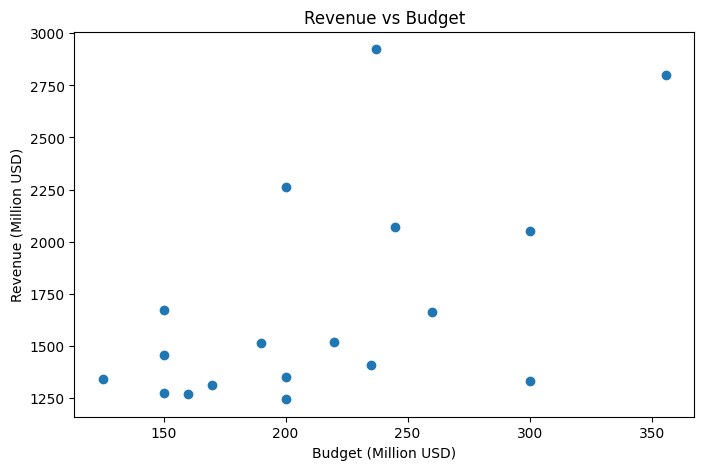

In [81]:
plt.scatter(df["budget_million"], df["revenue_million"])
plt.xlabel("Budget (Million USD)")
plt.ylabel("Revenue (Million USD)")
plt.title("Revenue vs Budget")

plt.show()

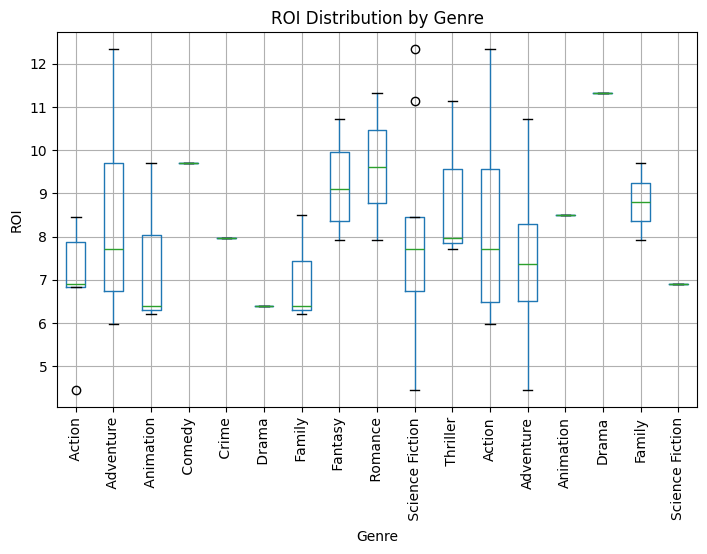

In [82]:
# Split genres
genre_df = df.copy()
genre_df["genres"] = genre_df["genres"].str.split("|")

# Explode
genre_df = genre_df.explode("genres")

# Filter valid ROI
genre_df = genre_df[genre_df["roi"].notna()]

# Boxplot
genre_df.boxplot(column="roi", by="genres", rot=90)

plt.title("ROI Distribution by Genre")
plt.suptitle("")  # remove default title
plt.xlabel("Genre")
plt.ylabel("ROI")

plt.show()

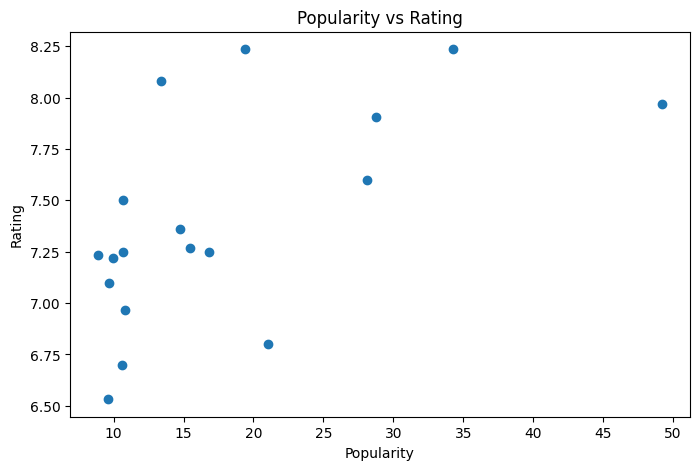

In [83]:
plt.scatter(df["popularity"], df["vote_average"])
plt.xlabel("Popularity")
plt.ylabel("Rating")
plt.title("Popularity vs Rating")

plt.show()

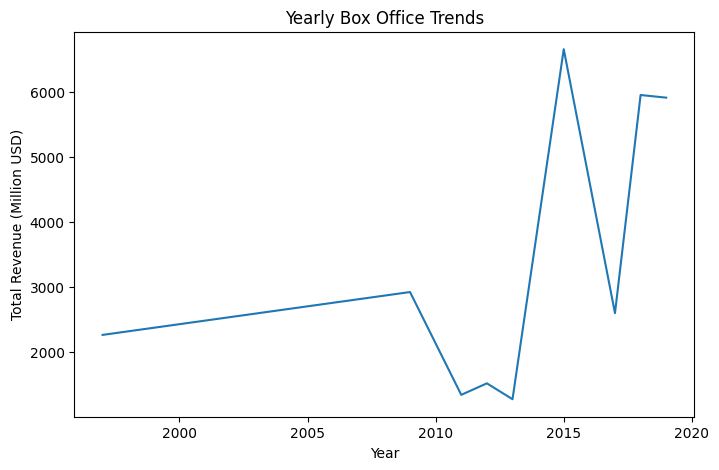

In [84]:
df["year"] = df["release_date"].dt.year
yearly = df.groupby("year")["revenue_million"].sum()
yearly.plot()

plt.xlabel("Year")
plt.ylabel("Total Revenue (Million USD)")
plt.title("Yearly Box Office Trends")

plt.show()

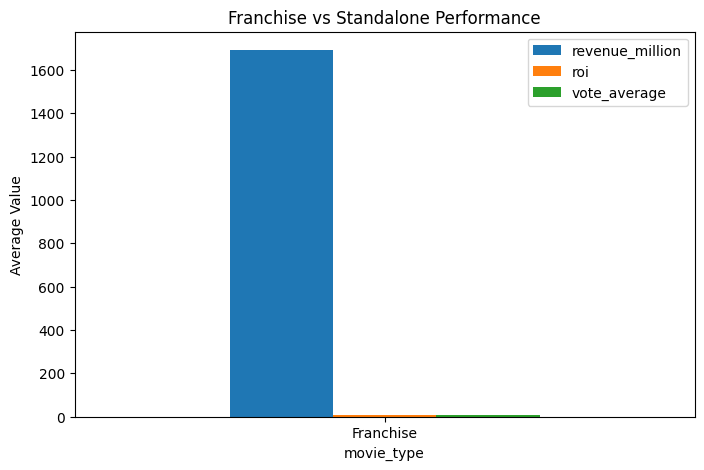

In [85]:
# Create type
df["movie_type"] = df["belongs_to_collection"].notna() & (df["belongs_to_collection"] != "None")
df["movie_type"] = df["movie_type"].map({True: "Franchise", False: "Standalone"})

# Aggregate
comparison = df.groupby("movie_type")[["revenue_million", "roi", "vote_average"]].mean()

# Plot
comparison.plot(kind="bar")

plt.title("Franchise vs Standalone Performance")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.show()